# LassoARE Quick-Start Demo (using scanpy built-in dataset)

This notebook demonstrates the LassoARE workflow using the lightweight, pre-processed **pbmc3k_processed** dataset built into Scanpy. 

In [1]:
import os
import sys
sys.path.append('.')

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random

# Load small built-in scanpy dataset (pbmc3k_processed)
print("Loading pbmc3k_processed dataset...")
adata = sc.datasets.pbmc3k_processed()
print(adata)

Loading pbmc3k_processed dataset...
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


### Step 1: Simulate User Selection
We will select cells from the `B cells` cluster to simulate a user selecting cells in a visualization tool.

In [2]:
obs_col = 'louvain'
target_cluster = 'B cells'
selected_list2 = np.where(adata.obs[obs_col] == target_cluster)[0].tolist()
print(f"Simulated selection size: {len(selected_list2)} cells")

Simulated selection size: 342 cells


### [Optional] Step 2: Refine selection with do_lasso
We run Label Propagation using the file-based `do_lasso_file` function. This step is an optional step for a refinement of few-shot priors.

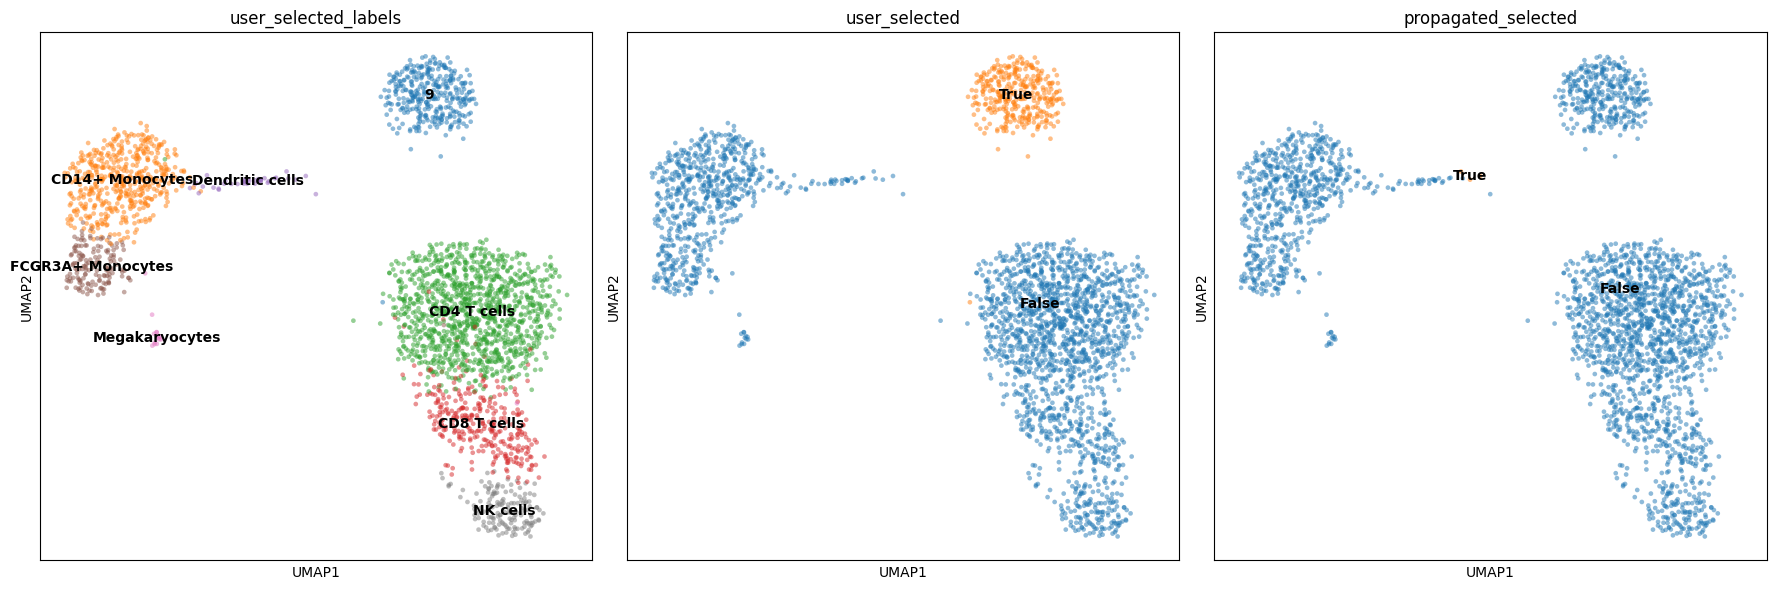

Initial Selection: 342 cells
Lasso Refined Selection: 345 cells


In [3]:
from do_lasso import do_lasso
lasso_list2 = do_lasso(adata, selected_list2, obs_col=obs_col, vis=True, vis_key=obs_col, do_correct=True)
print(f"Initial Selection: {len(selected_list2)} cells")
print(f"Lasso Refined Selection: {len(lasso_list2)} cells")

### Step 3: Prepare selection columns for visualization

In [4]:
selected_groups = [selected_list2]
lasso_groups = [lasso_list2]

selected_group = np.array(['False'] * adata.n_obs)
lasso_group = np.array(['False'] * adata.n_obs)
for i in selected_groups[0]:
    selected_group[i] = 'True'
for i in lasso_groups[0]:
    lasso_group[i] = 'True'
adata.obs['selected_group'] = pd.Categorical(selected_group)
adata.obs['lasso_group'] = pd.Categorical(lasso_group)

### Step 4: Run LassoARE Reclustering
We run `recluster_with_lasso_are` with fewer pretraining and GAN epochs to demonstrate the workflow quickly.

Number of user groups: 1
Total selected points: 345
Using device: cuda
Applying PCA: reducing from 1838 to 50 dimensions...
PCA on normalized data completed (no batch correction). Explained variance ratio: 0.1327
PCA on raw counts completed. Explained variance ratio: 0.2665
Number of user-selected groups: 1
Pretraining autoencoder...
Pretraining autoencoder...
Pretrain epoch [1/15], ZINB loss: 1.1577
Pretrain epoch [15/15], ZINB loss: 0.6798
Training adversarial clustering model...
Pretraining discriminators...
Pretrain Disc Epoch 10/15: Loss = 0.3306, Acc = 0.9981
--- Epoch 1/5 ---
  Disc Loss: 0.3288, Disc Acc: 0.9989
  Gen Loss: 0.8871
  Loss Components (Avg Weighted): Recon=0.6904, Cluster=0.1867, AdvAttn=0.0099
                              Inner=0.0000, Outer=0.0000, Consist=0.0000
  Group 1 distribution: {np.int64(0): np.int64(4), np.int64(1): np.int64(5), np.int64(7): np.int64(336)}
--- Epoch 5/5 ---
  Disc Loss: 0.3281, Disc Acc: 1.0000
  Gen Loss: 0.8657
  Loss Components (Av

/mnt/c/Code/lasso_are/project/submit/LassoARE/recluster_scRNA.py:251: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(leiden_adata, key_added='leiden_LassoARE', resolution=leiden_r)


Reclustering completed!
Result saved to: ./new_adata_fast/reclustered_adata_pbmc3k_42.h5ad
Plotting visualization comparisons...


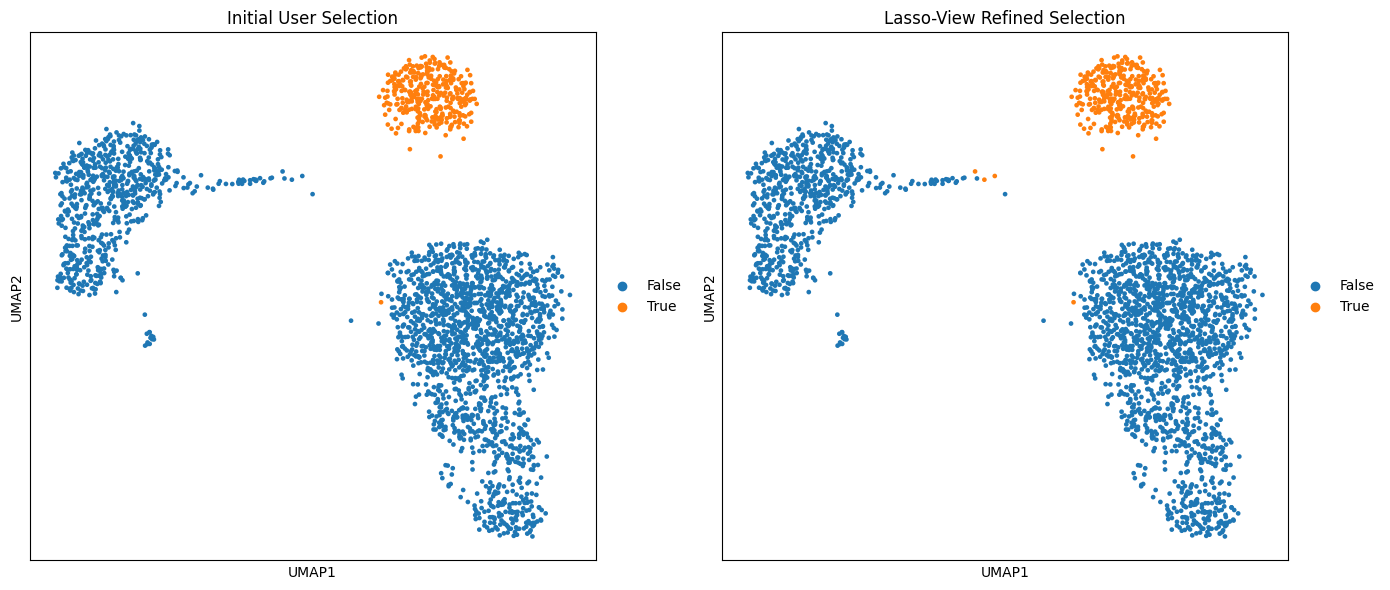

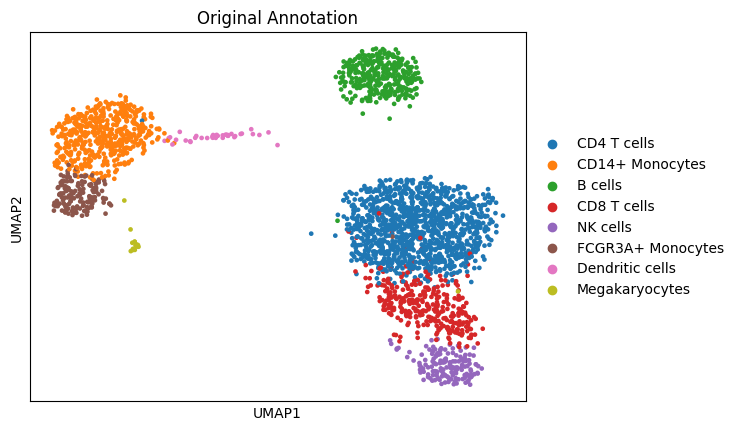

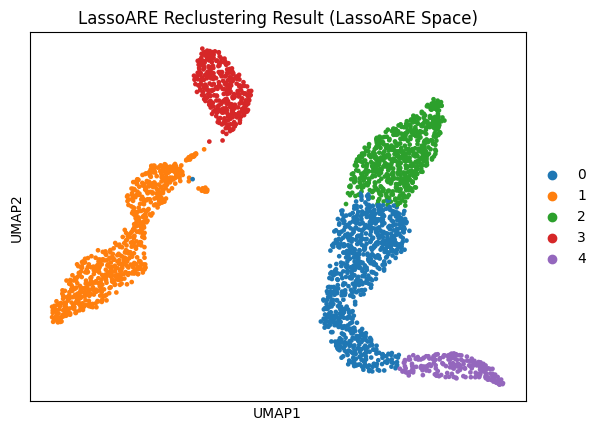

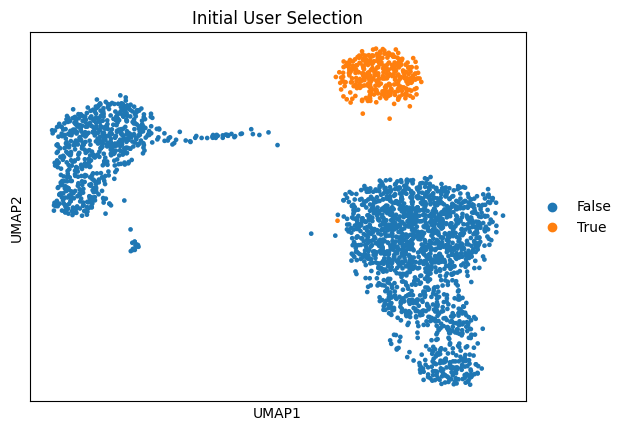

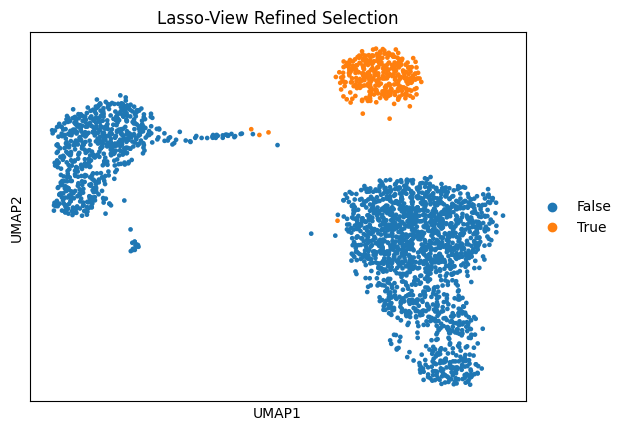

=== seed 42 completed ===



In [5]:
from LassoARE.recluster_scRNA import recluster_with_lasso_are

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def flatten_groups(groups):
    unique_indices = set()
    for group in groups:
        unique_indices.update(group)
    return sorted(unique_indices)
    
def conduct_recluster(lasso=True, seed=42):
    user_selected_groups = [lasso_list2] if lasso else [selected_list2]
    flat_selected = flatten_groups(user_selected_groups)
    
    print(f"Number of user groups: {len(user_selected_groups)}")
    print(f"Total selected points: {len(flat_selected)}")
    
    seed_everything(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Network layers
    enc_layers = [128, 32]
    dec_layers = [32, 128]
    disc_layers = [128, 32]
    
    reclustered_adata = recluster_with_lasso_are(
        adata=adata.copy(),
        user_selected_lists=user_selected_groups,
        n_clusters=8,             # pbmc3k has 8 louvain clusters
        enc_pretrain_epoch=15,    # Reduced epochs for quick startup
        disc_pretrain_epoch=15,
        gan_epoch=5,
        enc_layers=enc_layers,
        dec_layers=dec_layers,
        disc_layers=disc_layers,
        batch_size=128,
        device=device,
        lambda_attention=0.1,
        lambda_feature=0.0,
        lambda_consistency=0.0,
        lambda_cluster=1.0,
        lambda_recon=1.0,
        leiden_r=0.1,
        z_dim=16,
        is_pca=True,
        pca_dimension=50,
        do_pp=True,               # Generate downstream UMAP projection X_umap_LassoARE
        do_harmony=False,
    )
    
    output_dir = "./new_adata_fast"
    recluster_suffix = "" if lasso else "_woLasso"
    seed_str = "_" + str(seed)
    
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"reclustered_adata_pbmc3k{recluster_suffix}{seed_str}.h5ad")
    reclustered_adata.write_h5ad(output_path)
    print(f"Result saved to: {output_path}")
    
    # === Visualization ===
    print("Plotting visualization comparisons...")
    
    # 1. Initial selection vs Lasso refined selection on original UMAP
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sc.pl.umap(adata, color='selected_group', ax=axes[0], show=False, title='Initial User Selection')
    sc.pl.umap(adata, color='lasso_group', ax=axes[1], show=False, title='Lasso-View Refined Selection')
    plt.tight_layout()
    plt.show()

    # 2. Plot LassoARE reclustering result
    adata_copy = reclustered_adata.copy()
    adata_copy.obsm['X_umap'] = adata_copy.obsm['X_umap_LassoARE']
    sc.pl.umap(adata, color='louvain', title='Original Annotation')
    sc.pl.umap(adata_copy, color='leiden_LassoARE', title='LassoARE Reclustering Result (LassoARE Space)')
    sc.pl.umap(adata, color='selected_group', title='Initial User Selection')
    sc.pl.umap(adata, color='lasso_group', title='Lasso-View Refined Selection')
    
    if device.type == "cuda":
        torch.cuda.empty_cache()
    
    print(f"=== seed {seed} completed ===\n")

conduct_recluster(lasso=True, seed=42)